In [1]:
from __future__ import print_function
import numpy
import matplotlib.pyplot as plt
import warnings
%matplotlib inline


# HW 2:  Root Finding and Optimization

## Question 1 - Fun with Fixed Point iteration

Let's say that we wanted to calculate $\sqrt{M}$ given that $M \in \mathbb{R}$ and $M > 0$ and that we did not want to use the function `sqrt` directly.  Consider the function 

$$
    f(x) = x^2 - M
$$

which has a positive root at at $x=\sqrt{M}$.   Here we will try to solve this using  fixed point iteration

$$
    x_{k+1} = g(x_k)
$$
for several different iteration functions $g(x)$ (see below)

For each function $g$:

- Confirm analytically that $x=\sqrt{M}$ is a fixed point of $g(x)$
- Analyze the convergence behavior close to the fixed-point and determine the stability of the iterative scheme
- Now set $M=3$  and $x_0 = 2$.  Make a nicely labeled convergence plot showing the log of the relative error as a function of iteration. How many iterations are required to reduce the relative error to machine precision (if it converges)?

**Remember**: if you want to write $g^\prime$, remember to use `g^\prime` rather than `g'` in $\LaTeX$

**(a)** [4] To help with the last part,  write a short python function to return N iterations of a fixed point iteration.

In [12]:
def fixed_point(g, x0, N=5):
    """conduct N iterations of the fixed point iteration x_{k+1} = g(x_k)
    
    :Input:
        - *g* (function) - The iteration function
        - *x_0* (float) - Initial iterate
        - *N* (int) - number of terms in iteration
     
    :Output:
        x: numpy array (float)
            array containing the iterations [ x0, x1, ... x_N ]
    """
    x_k1 = numpy.zeros(N+1)
    x_k1[0] = x0
    for k in range(1,N+1):
        x_k1[k] = g(x0)
        x0=x_k1[k]
    return x_k1


In [4]:
### Free cell for messing with your code


In [9]:
# Testing Cell

N = 5
g = lambda x: numpy.cos(x)
x0 = 1.
answer = numpy.array([1., 0.54030231, 0.85755322, 0.65428979, 0.79348036, 0.70136877])

x = fixed_point(g, x0, N )
numpy.testing.assert_allclose(x, answer)
print('success: passed N=5 test')

x_true = 0.7390851332153119
x = fixed_point(g, x0, 1000)
numpy.testing.assert_almost_equal(x[-1],x_true)
print('success: passed N=1000 test')

success: passed N=5 test
success: passed N=1000 test


**(b)** [6] analyze the problem with 
$$ g(x) = 1 + x - \frac{x^2}{M}$$

Analytically confirming that $x=\sqrt(M)$ is a fixed point of $g(x)$:
$$
g(\sqrt{M}) = 1 + \sqrt M - \frac{(\sqrt M)^2}{M} \\
g(\sqrt{M}) = 1 + \sqrt M - 1 \\
g(\sqrt{M}) = \sqrt M = x \\
$$
This confirms $x = g(x)$ for this $M$ and $g$, which means this $M$ is a fixed point of this $g$.

Now analyze the convergence behavior of close to this fixed point and determine the stability of this iterative scheme. As was derived in this class' lecture, the stability of a fixed-point iterative scheme close to a fixed point (i.e. the error from the fixed point is small so higher order derivatives in a Taylor expansion of $g(x^*+e)$, where $x^*$ is a fixed point and $e$ is the error to the tested root, can be neglected) is dictated by the following expression:

$$
|g^\prime(x)| < 1 \\
$$

For this problem, this inequality becomes (for fixed point $\sqrt{M}$):

$$
|g^\prime(x)| = |1-\frac{2x}{M}| < 1 \\
|1-\frac{2\sqrt{M}}{M}| < 1 \\
|1-\frac{2}{\sqrt{M}}| < 1 \\
$$

Which is satisfied for $M>1$. Thus, this $g(x)$'s fixed point iteration will converge for $M>1$.

Machine parameters for float64
---------------------------------------------------------------
precision =  15   resolution = 1.0000000000000001e-15
machep =    -52   eps =        2.2204460492503131e-16
negep =     -53   epsneg =     1.1102230246251565e-16
minexp =  -1022   tiny =       2.2250738585072014e-308
maxexp =   1024   max =        1.7976931348623157e+308
nexp =       11   min =        -max
smallest_normal = 2.2250738585072014e-308   smallest_subnormal = 4.9406564584124654e-324
---------------------------------------------------------------



/var/folders/1s/jh18wdb5059c0177d80bb_xc0000gn/T/ipykernel_71220/2804452001.py:13: RuntimeWarning: divide by zero encountered in log
  plt.plot(numpy.linspace(1,N+1,N+1),numpy.log(rel_error))


Text(0, 0.5, 'ln of Relative Error')

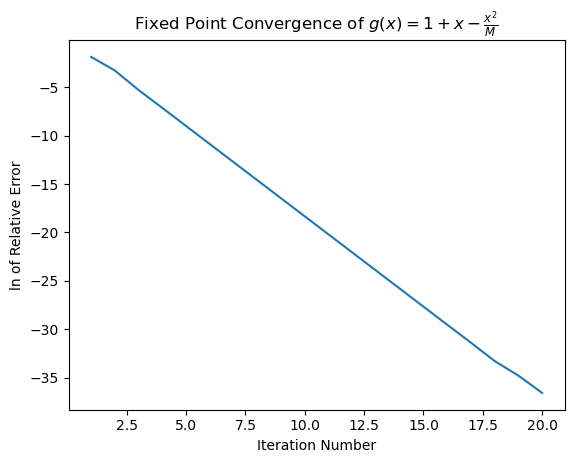

In [42]:
# Plot convergence with M=3 and x0=2
M=3
x0=2
N=1000
g = lambda x: 1+x-((x**2)/M)
f = numpy.sqrt(M)
xks = fixed_point(g=g,x0=x0,N=N)
rel_error = abs( (f - xks) / f )

print(numpy.finfo(rel_error[0]))

plt.figure(1)
plt.plot(numpy.linspace(1,N+1,N+1),numpy.log(rel_error))
plt.title(r"Fixed Point Convergence of $g(x)=1+x-\frac{x^2}{M}$")
plt.xlabel(r"Iteration Number")
# plt.ylabel(r"$ln(\frac{\sqrt{M} - x^*}{\sqrt{M}})$")
plt.ylabel("ln of Relative Error")

Relative Error:  
$$
    r = \frac{e}{|f|} = \frac{|f - F|}{|f|}
$$

As predicted, $M=3$, since it is greater than 1, converges. Machine precision for a float64 is indicated above to be about $2 * 10^{-16}$, but when looking at logs, this number is $ln(2 * 10^{-16}) \approx -36$, which occurs roughly after 20 iterations as is indicated on the plot above for this part.

In [41]:
print(numpy.log(2*10**(-16)))

-36.14821430734479


 **(c)** [6] analyze the problem with 
$$ g(x) = \frac{M}{x}$$

Same methodology as Part (b) of this problem.

Analytically confirming that $x=\sqrt(M)$ is a fixed point of $g(x)$:
$$
g(\sqrt{M}) = \frac{M}{\sqrt{M}} \\
g(\sqrt{M}) = \sqrt{M} = x \\
$$
This confirms $x = g(x)$ for this $M$ and $g$, which means this $M$ is a fixed point of this $g$.

Now analyze the convergence behavior of close to this fixed point and determine the stability of this iterative scheme. As was derived in this class' lecture, the stability of a fixed-point iterative scheme close to a fixed point (i.e. the error from the fixed point is small so higher order derivatives in a Taylor expansion of $g(x^*+e)$, where $x^*$ is a fixed point and $e$ is the error to the tested root, can be neglected) is dictated by the following expression:

$$
|g^\prime(x)| < 1 \\
$$

For this problem, this inequality becomes (for fixed point $\sqrt{M}$):

$$
|g^\prime(x)| = |\frac{-M}{x^2}| < 1 \\
|\frac{-M}{\sqrt{M}}| < 1 \\
|-1| < 1 \\
$$

This inequality cannot be satisfied by any value of $M$ and therefore no $M$ for this part's $g(x)$ will have a convergent fixed-point.

Text(0, 0.5, 'ln of Relative Error')

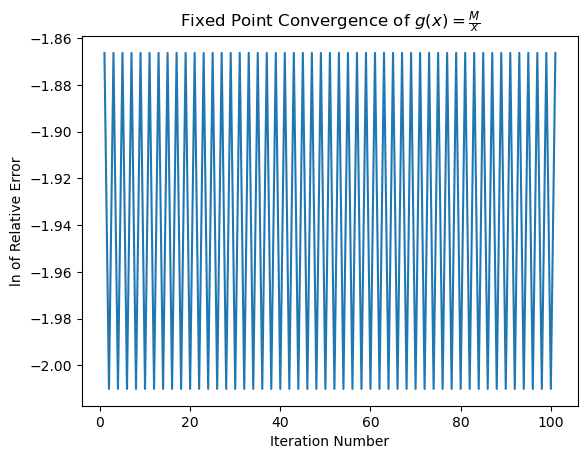

In [33]:
# Plot convergence with M=3 and x0=2
M=3
x0=2
N=100
g = lambda x: M/x
f = numpy.sqrt(M)
xks = fixed_point(g=g,x0=x0,N=N)
rel_error = abs( (f - xks) / f )

plt.figure(2)
plt.plot(numpy.linspace(1,N+1,N+1),numpy.log(rel_error))
plt.title(r"Fixed Point Convergence of $g(x)=\frac{M}{x}$")
plt.xlabel(r"Iteration Number")
# plt.ylabel(r"$ln(\frac{\sqrt{M} - x^*}{\sqrt{M}})$")
plt.ylabel("ln of Relative Error")

As predicted, this fixed-point iteration scheme does not converge.

**(d)** [6] Newton's method
$$ g(x) = x - \frac{f}{f^\prime}$$

with $$ f = x^2 - M$$

Same methodology as Part (b) of this problem.

$$
g(x) = x - \frac{x^2-M}{2x} = x - \frac{x}{2} + \frac{M}{2x} = \frac{x}{2} + \frac{M}{2x}
$$

Analytically confirming that $x=\sqrt(M)$ is a fixed point of $g(x)$:
$$
g(\sqrt{M}) = \sqrt{M} - \frac{\sqrt{M}^2-M}{2\sqrt{M}} = \sqrt{M} - 0 \\
g(\sqrt{M}) = \sqrt{M} = x \\
$$
This confirms $x = g(x)$ for this $M$ and $g$, which means this $M$ is a fixed point of this $g$.

Now analyze the convergence behavior of close to this fixed point and determine the stability of this iterative scheme. As was derived in this class' lecture, the stability of a fixed-point iterative scheme close to a fixed point (i.e. the error from the fixed point is small so higher order derivatives in a Taylor expansion of $g(x^*+e)$, where $x^*$ is a fixed point and $e$ is the error to the tested root, can be neglected) is dictated by the following expression:

$$
|g^\prime(x)| < 1 \\
$$

For this problem, this inequality becomes (for fixed point $\sqrt{M}$):

$$
|g^\prime(x)| = |\frac{1}{2} - \frac{M}{2x^2}| < 1 \\
|\frac{1}{2} - \frac{M}{2M}| < 1 \\
0 < 1 \\
$$

This inequality is always satisfied so for any $M$, convergence will always occur for this fixed point scheme.

/var/folders/1s/jh18wdb5059c0177d80bb_xc0000gn/T/ipykernel_71220/756354808.py:11: RuntimeWarning: divide by zero encountered in log
  plt.plot(numpy.linspace(1,N+1,N+1),numpy.log(rel_error))


Text(0, 0.5, 'ln of Relative Error')

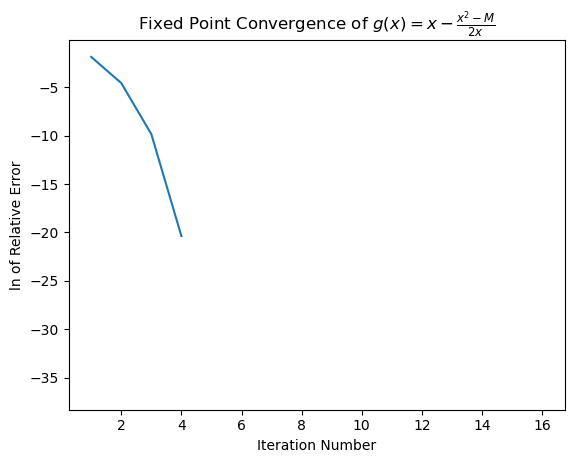

In [43]:
# Plot convergence with M=3 and x0=2
M=3
x0=2
N=15
g = lambda x: x - ((x**2)-M)/(2*x)
f = numpy.sqrt(M)
xks = fixed_point(g=g,x0=x0,N=N)
rel_error = abs( (f - xks) / f )

plt.figure(3)
plt.plot(numpy.linspace(1,N+1,N+1),numpy.log(rel_error))
plt.title(r"Fixed Point Convergence of $g(x) = x - \frac{x^2-M}{2x}$")
plt.xlabel(r"Iteration Number")
# plt.ylabel(r"$ln(\frac{\sqrt{M} - x^*}{\sqrt{M}})$")
plt.ylabel("ln of Relative Error")

As predicted, this fixed point scheme converges. Machine precision for a float64 is indicated above to be about $2 * 10^{-16}$, but when looking at logs, this number is $ln(2 * 10^{-16}) \approx -36$, which occurs roughly after 4 iterations as is indicated on the plot above for this part. I think this plot cuts off at -20 because the next point would be below machine precision!

## Question 2 - Fun with Rootfinders and NewtSafe

This problem will explore the behavior of a range of different rootfinding routines against  a more challenging rootfinding problem.  Feel free to use any or all  of the routines presented in class which have been included in an auxiliary python file `rootfinding_optimization_schemes.py`


You need to have this file in the same directory with your homework for this notebook to import it.

In [ ]:
#  Cell to import and test at least newton's method from class

from  rootfinding_optimization_schemes import newton

# set test function and its derivative
f = lambda x: numpy.cos(x) - x
f_prime = lambda x: -numpy.sin(x) - 1.

#set initial guess and call newton
x0 = 1.
x, x_array = newton(f, f_prime, x0,tol=1.e-12)

# run tests
answer = 0.7390851332151606
N = 5
numpy.testing.assert_almost_equal(x, answer)
numpy.testing.assert_almost_equal(N, len(x_array))
print("functions loaded correctly")

Consider the function 

$$
    f(x) = \cos(x) +  N(x, A, \alpha, \beta))
$$
where

$$
    N(x, A, \alpha, \beta) =  A\left[\sin(\alpha x) + \sin(\beta x)\right]
$$

is a function that adds smooth additive "noise" with fixed amplitude $A = 0.05$ and varying frequencies $\alpha$ and $\beta$

**(a)** [4] Make a nicely labeled plot to showing the behavior of this function for 
* $\alpha = 0.$, $\beta =0.$
* $\alpha = 4.$, $\beta =5.$
* $\alpha = 27$, $\beta = 50$

over the domain $x\in[-2\pi, 2\pi]$. Make sure you have enough points to resolve the wiggles.  You can plot all three curves on the same plot

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

**(b)** [4] Explore the behavior of the following rootfinding routines 
* bisection
* newton
* secant
* brentq method using scipy.optimize.root_scalar
* **EXTRA CREDIT** any other method used in root_scalar

for finding a root of this function, given the bracket $x\in[x_0, x_1]$ with $x_0 = 0.2$, $x_1 = 2.$ for each ($\alpha, \beta$) pair

`params = [ (0., 0.), (4., 5.),  (27, 50.) ]`

For each routine,  report
* the root found $x^*$
* the value of $f$ at the root $f(x^*$)
* the number of iterations.

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

**(c)** [4] Make a convergence plot showing the relative error of each iteration $x_k$ with respect to the final root $x_N$ found  using Newton's method with the same three parameter pairs and initial guess $x_0 = 0.2$. 

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

**(d)** [4] Briefly explain your results so far for all the methods.  Feel free to play with other initial parameters or to make additional plots.  

YOUR ANSWER HERE

**(e)** [6] Write a controlled Newton routine `NewtSafe`,  that finds a root with an initial bracket by combining newton steps with a bisection routine.  The basic algorithm is to first try Newton from the midpoint of the bracket.  If Newton predicts a solution outside of the bracket, ignore it and take a bisection step instead.  You can use and modify any of the rootfinding routines I presented in class, but write a decent docstring and raise appropriate exceptions as necessary. 

The routine should return the best estimate of the root and number of Newton Steps and the number of bisection steps

`x, N_newt, N_bisection = newtsafe(f, f_prime, a, b)`

In [ ]:
def newtsafe(f,f_prime,a,b,tol = 1.e-6, max_steps=1000):
    """ Please improve this docstring
        
    
    Parameters:
    -----------
    
    f: function (float)
        function returning f(x)
    f_prime:  function (float)
        function returning derivative of f with respect to x
    a: float
        left bracket a < x
    b: float
        right bracket x < b
        
        Note:  the signs of f(a) and f(b) must be different to insure a bracket
    tol: float
        tolerance.  Returns when |f(x)| < tol
    max_steps: int
        maximum number of iteration steps
        
    Returns:
    --------
    x: float
        midpoint of final bracket
    n_newt:  number of newton steps for successful newton iteration
    n_bisection: number of bisection steps
        
    Raises:
    -------
    ValueError:  
        if initial bracket is invalid 
    Warning: 
        if number of iterations exceed MAX_STEPS
    Prints warning if Newton exceeds the bracket
    
    """
# YOUR CODE HERE
raise NotImplementedError()


In [ ]:
# you can play with your code here

In [ ]:
# Testing Cell
from  rootfinding_optimization_schemes import newton
from scipy.optimize import root_scalar

a = 27
b = 50
A = 0.3
f = lambda x: numpy.cos(x) + A*(numpy.sin(a * x) + numpy.sin(b * x))
f_prime = lambda x: -numpy.sin(x) + A*(a*numpy.cos(a * x) + b*numpy.cos(b * x))

pi = numpy.pi

brackets = [ 
            (-0.68309670780092, 2.642524050776319),
            (-0.7104536143852529, 3.8152626763086603),
            (-0.5236057894835726, 3.9067882124238986),
            (-0.5275356434135271, 2.4988039593212776),
            (-0.3534683303763972, 3.9130408021252014)
           ]

for bracket in brackets:
    #a = numpy.random.uniform(low=-pi/4, high=pi/4)
    #b = numpy.random.uniform(low=3*pi/4, high=5*pi/4)
    a = bracket[0]
    b = bracket[1]
    x_n, x_array = newton(f, f_prime, (a + b)/2.)
    x_ns, N_n, N_b = newtsafe(f, f_prime, a, b)
    sol = root_scalar(f, bracket=(a, b),method='brentq')
    print('Bracket  = [{}, {}]'.format(a, b))
    print('Newton   = {},    N   = {}'.format(x_n, len(x_array)-1))
    print('NewtSafe = {},    N_n = {}, N_b = {}'.format(x_ns, N_n, N_b))
    print('brentq   = {},    N   = {}'.format(sol.root, sol.iterations))
    print()
    numpy.testing.assert_almost_equal(x_ns, sol.root,decimal=5)
    
try:
    x_ns, N_n, N_b = newtsafe(f, f_prime, 1.6, 2.0)
except ValueError as err:
    print(err)
    pass

print('success!')


## Question 3 - Solve a "real" rootfinding problem

In Homework 2, I asked you to *estimate* the number of terms in the taylor expansion of $e^x$ such that the relative error was less than $\epsilon_{mach}$.  This was essentially a non-linear problem in the number of steps $n$.  Here we will use a rootfinder to get this number more precisely.

**(a)** [8] provide a numerical solution for the number of terms $n$ in the Taylor polynomial expansion of exp(x) (i.e. $T_N(x))$ such that the relative error is

$$
    r = \left| \frac{x^{n+1}}{(n + 1)!} \right| \approx \epsilon_{mach}
$$ 

Give solutions for x = 0.1, 1., 10. ,100. , 709., 1000. and compare your numerical solution to the approximate solution given in last homework 

$$
    n > e*x
$$

by calculating the relative error between the your numerical solution and your simpler estimate.

Note: To make this problem easier, just use Stirling’s approximation $\log(n!) \approx n \log n − n$. which will work quite well.  However, for a little bit of extra credit solve this for the full problem and compare solutions.


YOUR ANSWER HERE

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()